# Mutual Fund Performance Analytics

## Day 4 – Performance Analytics

This notebook performs comprehensive performance analysis for the selected mutual funds.

### Objectives

- Load historical NAV and benchmark data
- Compute daily returns
- Calculate CAGR (1Y, 3Y, 5Y)
- Compute Sharpe Ratio
- Compute Sortino Ratio
- Estimate Alpha & Beta using OLS Regression against NIFTY 100
- Calculate Maximum Drawdown
- Compute Tracking Error
- Generate Fund Scorecard (0–100)
- Compare top-performing funds against benchmarks
- Export analytical reports

**Outputs**

- `reports/fund_scorecard.csv`
- `reports/alpha_beta.csv`
- `charts/benchmark_comparison.png`

---

In [57]:
# ============================================================
# Performance Analytics
# ============================================================

from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from scipy.stats import linregress
import statsmodels.api as sm

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger(__name__)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [58]:
# ============================================================
# Project Configuration
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DB_PATH = PROJECT_ROOT / "bluestock_mf.db"

BENCHMARK_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "10_benchmark_indices.csv"
)

REPORT_DIR = PROJECT_ROOT / "reports"
CHART_DIR = PROJECT_ROOT / "charts"

REPORT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

# Annual risk-free rate (RBI Repo Rate)
RISK_FREE_RATE = 0.065

TRADING_DAYS = 252

print("Project Root :", PROJECT_ROOT)
print("Database     :", DB_PATH)
print("Benchmark    :", BENCHMARK_FILE)

Project Root : c:\Users\khush\Desktop\MutualFundAnalytics
Database     : c:\Users\khush\Desktop\MutualFundAnalytics\bluestock_mf.db
Benchmark    : c:\Users\khush\Desktop\MutualFundAnalytics\data\processed\10_benchmark_indices.csv


In [59]:
# ============================================================
# Connect to SQLite
# ============================================================

conn = sqlite3.connect(DB_PATH)

print("Database connected successfully.")

Database connected successfully.


In [60]:
# ============================================================
# Verify Tables
# ============================================================

tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name;
    """,
    conn,
)

display(tables)

,name
0,dim_date
1,dim_fund
2,fact_aum
3,fact_nav
4,fact_performance
5,fact_transactions
6,sqlite_sequence


In [61]:
# ============================================================
# Inspect Schemas
# ============================================================

for table in tables["name"]:
    print("=" * 60)
    print(table)
    print("=" * 60)

    schema = pd.read_sql(
        f"PRAGMA table_info({table});",
        conn
    )

    display(schema)

dim_date


,cid,name,type,notnull,dflt_value,pk
0,0,date_id,BIGINT,0,None,0
1,1,full_date,DATETIME,0,None,0


dim_fund


,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,scheme_name,TEXT,0,None,0
2,2,fund_house,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,sub_category,TEXT,0,None,0
5,5,plan,TEXT,0,None,0
6,6,fund_manager,TEXT,0,None,0
7,7,risk_category,TEXT,0,None,0


fact_aum


...

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,scheme_name,TEXT,0,None,0
2,2,fund_house,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,plan,TEXT,0,None,0
5,5,return_1yr_pct,FLOAT,0,None,0
6,6,return_3yr_pct,FLOAT,0,None,0
7,7,return_5yr_pct,FLOAT,0,None,0
8,8,benchmark_3yr_pct,FLOAT,0,None,0
9,9,alpha,FLOAT,0,None,0


fact_transactions


,cid,name,type,notnull,dflt_value,pk
0,0,transaction_id,TEXT,0,None,0
1,1,transaction_date,TEXT,0,None,0
2,2,amfi_code,BIGINT,0,None,0
3,3,transaction_type,TEXT,0,None,0
4,4,amount_inr,BIGINT,0,None,0
5,5,state,TEXT,0,None,0
6,6,city,TEXT,0,None,0
7,7,city_tier,TEXT,0,None,0
8,8,age_group,TEXT,0,None,0
9,9,gender,TEXT,0,None,0


sqlite_sequence


,cid,name,type,notnull,dflt_value,pk
0,0,name,,0,None,0
1,1,seq,,0,None,0


In [62]:
# ============================================================
# Load NAV History with Fund Details
# ============================================================

query = """
SELECT
    fn.amfi_code,
    df.scheme_name,
    df.fund_house,
    df.category,
    df.sub_category,
    fp.expense_ratio_pct,
    dd.full_date,
    fn.nav

FROM fact_nav fn

INNER JOIN dim_date dd
    ON fn.date_id = dd.date_id

INNER JOIN dim_fund df
    ON fn.amfi_code = df.amfi_code

LEFT JOIN fact_performance fp
    ON fn.amfi_code = fp.amfi_code

ORDER BY
    df.scheme_name,
    dd.full_date;
"""

nav_df = pd.read_sql(query, conn)

# Convert data types
nav_df["full_date"] = pd.to_datetime(nav_df["full_date"])
nav_df["nav"] = pd.to_numeric(nav_df["nav"])

print(f"Rows Loaded : {len(nav_df):,}")
print(f"Funds       : {nav_df['scheme_name'].nunique()}")
print(f"Date Range  : {nav_df['full_date'].min().date()} → {nav_df['full_date'].max().date()}")

display(nav_df.head())

Rows Loaded : 46,000
Funds       : 40
Date Range  : 2022-01-03 → 2026-05-29


,amfi_code,scheme_name,fund_house,category,sub_category,expense_ratio_pct,full_date,nav
0,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-03,305.099600
1,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-04,305.451400
2,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-05,306.632400
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-06,305.980000
4,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-07,304.048000


In [63]:
# ============================================================
# Load Benchmark Indices
# ============================================================

benchmark_df = pd.read_csv(BENCHMARK_FILE)

benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])
benchmark_df["close_value"] = pd.to_numeric(benchmark_df["close_value"])

print("Benchmark Shape :", benchmark_df.shape)

display(benchmark_df.head())


Benchmark Shape : (8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,"17,492.790000"
1,2022-01-04,NIFTY50,"17,689.640000"
2,2022-01-05,NIFTY50,"17,835.050000"
3,2022-01-06,NIFTY50,"17,878.510000"
4,2022-01-07,NIFTY50,"17,759.150000"


In [64]:
# ============================================================
# Daily Benchmark Returns
# ============================================================

benchmark_returns = (
    benchmark_df
    .sort_values(["index_name", "date"])
    .copy()
)

benchmark_returns["benchmark_return"] = (
    benchmark_returns
    .groupby("index_name")["close_value"]
    .pct_change()
)

display(benchmark_returns.head())

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,"26,554.600000",NaN
3451,2022-01-04,BSE_SMALLCAP,"27,079.920000",0.019783
3452,2022-01-05,BSE_SMALLCAP,"27,313.350000",0.008620
3453,2022-01-06,BSE_SMALLCAP,"27,377.050000",0.002332
3454,2022-01-07,BSE_SMALLCAP,"26,316.860000",-0.038726


In [65]:
# ============================================================
# Daily Fund Returns
# ============================================================

nav_df = nav_df.sort_values(
    ["scheme_name", "full_date"]
).copy()

nav_df["daily_return"] = (
    nav_df
    .groupby("scheme_name")["nav"]
    .pct_change()
)

print("Daily returns calculated.")

display(nav_df.head(15))

Daily returns calculated.


,amfi_code,scheme_name,fund_house,category,sub_category,expense_ratio_pct,full_date,nav,daily_return
0,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-03,305.099600,NaN
1,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-04,305.451400,0.001153
2,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-05,306.632400,0.003866
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-06,305.980000,-0.002128
4,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-07,304.048000,-0.006314
5,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-10,307.559100,0.011548
6,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-11,309.437200,0.006106
7,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-12,313.202200,0.012167
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-13,310.739600,-0.007863
9,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,1.600000,2022-01-14,308.964100,-0.005714


In [66]:
# ============================================================
# Data Validation
# ============================================================

summary = (
    nav_df
    .groupby("scheme_name")["daily_return"]
    .agg(
        observations="count",
        mean="mean",
        std="std",
        minimum="min",
        maximum="max"
    )
)

display(summary)

,observations,mean,std,minimum,maximum
scheme_name,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1149,0.000852,0.009177,-0.038121,0.033956
ABSL Liquid Fund - Regular - Growth,1149,0.000242,0.000319,-0.000766,0.001247
ABSL Small Cap Fund - Regular - Growth,1149,0.000424,0.016251,-0.051847,0.054851
Axis Bluechip Fund - Direct - Growth,1149,0.000330,0.008809,-0.029496,0.030558
Axis Bluechip Fund - Regular - Growth,1149,0.000275,0.008788,-0.023383,0.033626
Axis Midcap Fund - Regular - Growth,1149,0.001027,0.012225,-0.040755,0.041591
Axis Small Cap Fund - Regular - Growth,1149,0.000182,0.015790,-0.048367,0.043110
DSP Midcap Fund - Regular - Growth,1149,0.001055,0.011179,-0.030092,0.041995
DSP Small Cap Fund - Regular - Growth,1149,0.001194,0.015648,-0.048870,0.048490


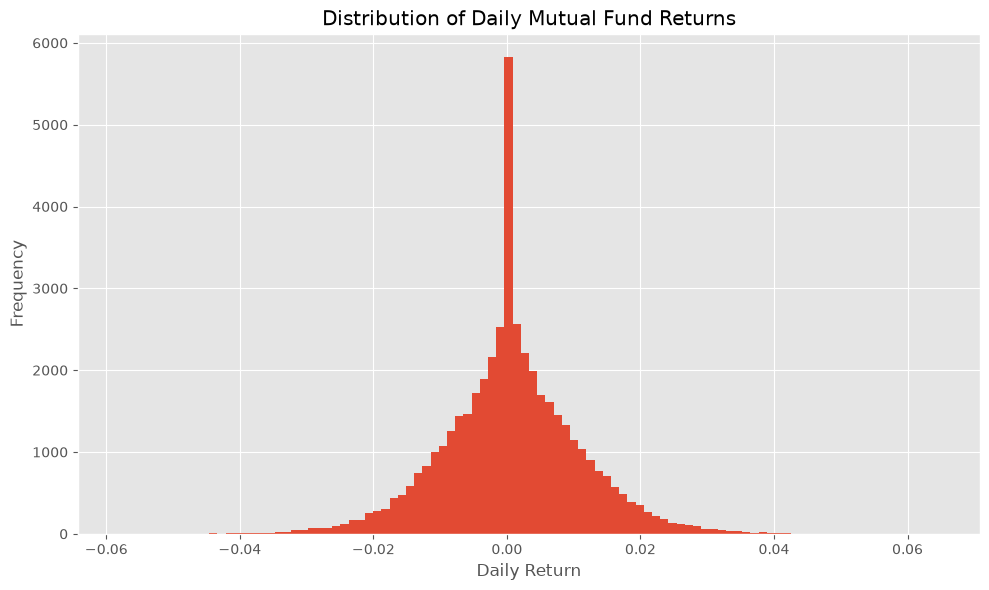

In [67]:
# ============================================================
# Daily Return Distribution
# ============================================================

plt.figure(figsize=(10,6))

nav_df["daily_return"].dropna().hist(
    bins=100
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [68]:
# ============================================================
# CAGR Calculation
# ============================================================

def calculate_cagr(group: pd.DataFrame, years: int) -> float:
    """
    Calculate CAGR over the specified number of years.

    Parameters
    ----------
    group : DataFrame
        NAV history for a single fund.
    years : int
        Number of years.

    Returns
    -------
    float
        CAGR as decimal.
    """
    group = group.sort_values("full_date")

    end_date = group["full_date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period = group[group["full_date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]
    end_nav = period.iloc[-1]["nav"]

    if start_nav <= 0:
        return np.nan

    return (end_nav / start_nav) ** (1 / years) - 1


fund_metrics = (
    nav_df.groupby("scheme_name")
    .apply(
        lambda g: pd.Series({
            "CAGR_1Y": calculate_cagr(g, 1),
            "CAGR_3Y": calculate_cagr(g, 3),
            "CAGR_5Y": calculate_cagr(g, 5),
        })
    )
    .reset_index()
)

display(fund_metrics.head())

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
1,ABSL Liquid Fund - Regular - Growth,0.072366,0.063158,0.057057
2,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533
3,Axis Bluechip Fund - Direct - Growth,0.197667,0.208168,0.069174
4,Axis Bluechip Fund - Regular - Growth,0.016091,0.005259,0.055826


In [69]:
# ============================================================
# Sharpe Ratio
# ============================================================

def calculate_sharpe(group: pd.DataFrame) -> float:
    """
    Calculate annualized Sharpe Ratio.
    Formula:
    ((Mean Daily Return - Daily Risk-Free Rate) / Daily Std Dev) * sqrt(252)
    """

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        return np.nan

    mean_daily_return = returns.mean()

    daily_std = returns.std()

    if daily_std == 0:
        return np.nan

    daily_rf = RISK_FREE_RATE / TRADING_DAYS

    sharpe = (
        (mean_daily_return - daily_rf)
        / daily_std
    ) * np.sqrt(TRADING_DAYS)

    return sharpe


sharpe_df = (
    nav_df
    .groupby("scheme_name")
    .apply(calculate_sharpe)
    .reset_index(name="Sharpe_Ratio")
)

display(sharpe_df.head())

,scheme_name,Sharpe_Ratio
0,ABSL Frontline Equity Fund - Regular - Growth,1.027213
1,ABSL Liquid Fund - Regular - Growth,-0.815567
2,ABSL Small Cap Fund - Regular - Growth,0.162661
3,Axis Bluechip Fund - Direct - Growth,0.129614
4,Axis Bluechip Fund - Regular - Growth,0.030785


In [70]:
# ============================================================
# Sortino Ratio
# ============================================================

def calculate_sortino(group: pd.DataFrame) -> float:
    """
    Calculate annualized Sortino Ratio.
    Formula:
    ((Mean Daily Return - Daily Risk-Free Rate) /
     Downside Std Dev) * sqrt(252)
    """

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        return np.nan

    downside = returns[returns < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std()

    if downside_std == 0:
        return np.nan

    mean_daily_return = returns.mean()

    daily_rf = RISK_FREE_RATE / TRADING_DAYS

    sortino = (
        (mean_daily_return - daily_rf)
        / downside_std
    ) * np.sqrt(TRADING_DAYS)

    return sortino


sortino_df = (
    nav_df
    .groupby("scheme_name")
    .apply(calculate_sortino)
    .reset_index(name="Sortino_Ratio")
)

display(sortino_df.head())

,scheme_name,Sortino_Ratio
0,ABSL Frontline Equity Fund - Regular - Growth,1.799563
1,ABSL Liquid Fund - Regular - Growth,-1.681038
2,ABSL Small Cap Fund - Regular - Growth,0.276644
3,Axis Bluechip Fund - Direct - Growth,0.221087
4,Axis Bluechip Fund - Regular - Growth,0.052574


In [71]:
# ============================================================
# Maximum Drawdown
# ============================================================

def calculate_max_drawdown(group):

    nav = group["nav"]

    running_max = nav.cummax()

    drawdown = (nav - running_max) / running_max

    return drawdown.min()


maxdd_df = (
    nav_df.groupby("scheme_name")
    .apply(calculate_max_drawdown)
    .reset_index(name="Max_Drawdown")
)

display(maxdd_df.head())

,scheme_name,Max_Drawdown
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916
1,ABSL Liquid Fund - Regular - Growth,-0.001622
2,ABSL Small Cap Fund - Regular - Growth,-0.354469
3,Axis Bluechip Fund - Direct - Growth,-0.217514
4,Axis Bluechip Fund - Regular - Growth,-0.144016


In [72]:
# ============================================================
# Prepare NIFTY100 Returns
# ============================================================

nifty100 = benchmark_returns[
    benchmark_returns["index_name"]
    .str.upper()
    .str.contains("100")
].copy()

nifty100 = nifty100[
    ["date", "benchmark_return"]
].dropna()

display(nifty100.head())

,date,benchmark_return
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150
1155,2022-01-10,-0.008351


In [73]:
# ============================================================
# Alpha & Beta
# ============================================================

alpha_beta = []

for scheme, group in nav_df.groupby("scheme_name"):

    merged = group.merge(
        nifty100,
        left_on="full_date",
        right_on="date",
        how="inner"
    )

    merged = merged.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    if len(merged) < 30:
        continue

    X = merged["benchmark_return"]

    # Add intercept (constant)
    X = sm.add_constant(X)

    y = merged["daily_return"]

    model = sm.OLS(y, X).fit()

    beta = model.params["benchmark_return"]
    alpha = model.params["const"] * TRADING_DAYS

    alpha_beta.append({
        "scheme_name": scheme,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

display(alpha_beta_df.head())

,scheme_name,Alpha,Beta
0,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
1,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267
2,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289
3,Axis Bluechip Fund - Direct - Growth,0.082328,0.025883
4,Axis Bluechip Fund - Regular - Growth,0.068995,0.009731


In [74]:
# ============================================================
# Merge Performance Metrics
# ============================================================

performance_df = (
    fund_metrics
    .merge(sharpe_df, on="scheme_name")
    .merge(sortino_df, on="scheme_name")
    .merge(maxdd_df, on="scheme_name")
    .merge(alpha_beta_df, on="scheme_name")
)

display(performance_df.head())

print(f"Funds Analysed : {len(performance_df)}")

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Alpha,Beta
0,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427,1.027213,1.799563,-0.112916,0.213998,0.021086
1,ABSL Liquid Fund - Regular - Growth,0.072366,0.063158,0.057057,-0.815567,-1.681038,-0.001622,0.060861,0.000267
2,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533,0.162661,0.276644,-0.354469,0.108971,-0.065289
3,Axis Bluechip Fund - Direct - Growth,0.197667,0.208168,0.069174,0.129614,0.221087,-0.217514,0.082328,0.025883
4,Axis Bluechip Fund - Regular - Growth,0.016091,0.005259,0.055826,0.030785,0.052574,-0.144016,0.068995,0.009731


Funds Analysed : 40


In [75]:
# ============================================================
# Tracking Error
# ============================================================

tracking_error = []

for scheme, group in nav_df.groupby("scheme_name"):

    merged = group.merge(
        nifty100,
        left_on="full_date",
        right_on="date",
        how="inner"
    )

    merged = merged.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    if len(merged) < 30:
        continue

    active_return = (
        merged["daily_return"] -
        merged["benchmark_return"]
    )

    te = active_return.std() * np.sqrt(TRADING_DAYS)

    tracking_error.append({
        "scheme_name": scheme,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

display(tracking_error_df.head())


,scheme_name,Tracking_Error
0,ABSL Frontline Equity Fund - Regular - Growth,0.192706
1,ABSL Liquid Fund - Regular - Growth,0.128957
2,ABSL Small Cap Fund - Regular - Growth,0.292117
3,Axis Bluechip Fund - Direct - Growth,0.187900
4,Axis Bluechip Fund - Regular - Growth,0.189082


In [76]:
# ============================================================
# Add Expense Ratio
# ============================================================

expense_df = (
    nav_df[
        ["scheme_name", "expense_ratio_pct"]
    ]
    .drop_duplicates()
)

performance_df = performance_df.merge(
    expense_df,
    on="scheme_name",
    how="left"
)

performance_df = performance_df.merge(
    tracking_error_df,
    on="scheme_name",
    how="left"
)

display(performance_df.head())

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Alpha,Beta,expense_ratio_pct,Tracking_Error
0,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427,1.027213,1.799563,-0.112916,0.213998,0.021086,1.600000,0.192706
1,ABSL Liquid Fund - Regular - Growth,0.072366,0.063158,0.057057,-0.815567,-1.681038,-0.001622,0.060861,0.000267,0.790000,0.128957
2,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533,0.162661,0.276644,-0.354469,0.108971,-0.065289,1.530000,0.292117
3,Axis Bluechip Fund - Direct - Growth,0.197667,0.208168,0.069174,0.129614,0.221087,-0.217514,0.082328,0.025883,0.750000,0.187900
4,Axis Bluechip Fund - Regular - Growth,0.016091,0.005259,0.055826,0.030785,0.052574,-0.144016,0.068995,0.009731,1.640000,0.189082


In [77]:
# ============================================================
# Fund Scorecard
# ============================================================

score_df = performance_df.copy()

# Higher is better
score_df["Return_Score"] = (
    score_df["CAGR_3Y"].rank(pct=True) * 30
)

score_df["Sharpe_Score"] = (
    score_df["Sharpe_Ratio"].rank(pct=True) * 25
)

score_df["Alpha_Score"] = (
    score_df["Alpha"].rank(pct=True) * 20
)

# Lower is better
score_df["Expense_Score"] = (
    (1 - score_df["expense_ratio_pct"].rank(pct=True)) * 15
)

score_df["Drawdown_Score"] = (
    (1 - score_df["Max_Drawdown"].abs().rank(pct=True)) * 10
)

score_df["Fund_Score"] = (
      score_df["Return_Score"]
    + score_df["Sharpe_Score"]
    + score_df["Alpha_Score"]
    + score_df["Expense_Score"]
    + score_df["Drawdown_Score"]
)

score_df = score_df.sort_values(
    "Fund_Score",
    ascending=False
)

display(score_df.head(10))

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Alpha,Beta,expense_ratio_pct,Tracking_Error,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
25,Mirae Asset Large Cap Fund - Regular - Growth,0.203607,0.340009,0.267993,1.448291,2.385644,-0.112657,0.269838,0.023684,1.460000,0.189664,29.250000,25.000000,17.000000,6.375000,8.000000,85.625000
18,ICICI Pru Midcap Fund - Regular - Growth,0.296047,0.317775,0.283768,1.180101,2.029353,-0.181885,0.292636,0.000549,1.360000,0.231968,27.000000,22.500000,19.000000,9.375000,3.750000,81.625000
22,Kotak Flexicap Fund - Regular - Growth,0.266571,0.295828,0.267425,1.306744,2.364320,-0.129740,0.273305,-0.022830,1.450000,0.206425,25.500000,24.375000,18.000000,6.750000,6.750000,81.375000
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741,1.093699,1.829134,-0.162172,0.271954,0.005104,1.380000,0.228699,27.750000,21.250000,17.500000,8.625000,5.000000,80.125000
15,ICICI Pru Bluechip Fund - Direct - Growth,0.130643,0.324874,0.202340,1.026524,1.805294,-0.125883,0.211948,0.016232,0.800000,0.191587,28.500000,19.375000,14.000000,10.500000,7.000000,79.375000
5,Axis Midcap Fund - Regular - Growth,0.222611,0.351118,0.244453,0.998231,1.703797,-0.209609,0.260767,-0.066265,1.380000,0.237652,30.000000,18.750000,16.000000,8.625000,3.000000,76.375000
33,SBI Bluechip Fund - Regular Plan - Growth,0.604373,0.304565,0.223849,1.208267,2.140267,-0.150124,0.232010,-0.031751,1.540000,0.191183,26.250000,23.125000,15.500000,3.562500,5.750000,74.187500
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.397518,0.291789,0.276299,1.234930,2.146914,-0.163967,0.282704,0.018134,1.600000,0.217365,24.750000,23.750000,18.500000,1.312500,4.750000,73.062500
0,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427,1.027213,1.799563,-0.112916,0.213998,0.021086,1.600000,0.192706,24.000000,20.000000,14.500000,1.312500,7.750000,67.562500
36,SBI Small Cap Fund - Regular Plan - Growth,0.827761,0.266699,0.280332,0.945308,1.675317,-0.287060,0.303370,-0.023196,1.430000,0.283881,21.750000,16.875000,20.000000,7.125000,1.000000,66.750000


In [78]:
# ============================================================
# Export CSV Reports
# ============================================================

alpha_beta_path = REPORT_DIR / "alpha_beta.csv"
scorecard_path = REPORT_DIR / "fund_scorecard.csv"

alpha_beta_df.to_csv(
    alpha_beta_path,
    index=False
)

score_df.to_csv(
    scorecard_path,
    index=False
)

print("Saved:")
print(alpha_beta_path)
print(scorecard_path)

Saved:
c:\Users\khush\Desktop\MutualFundAnalytics\reports\alpha_beta.csv
c:\Users\khush\Desktop\MutualFundAnalytics\reports\fund_scorecard.csv


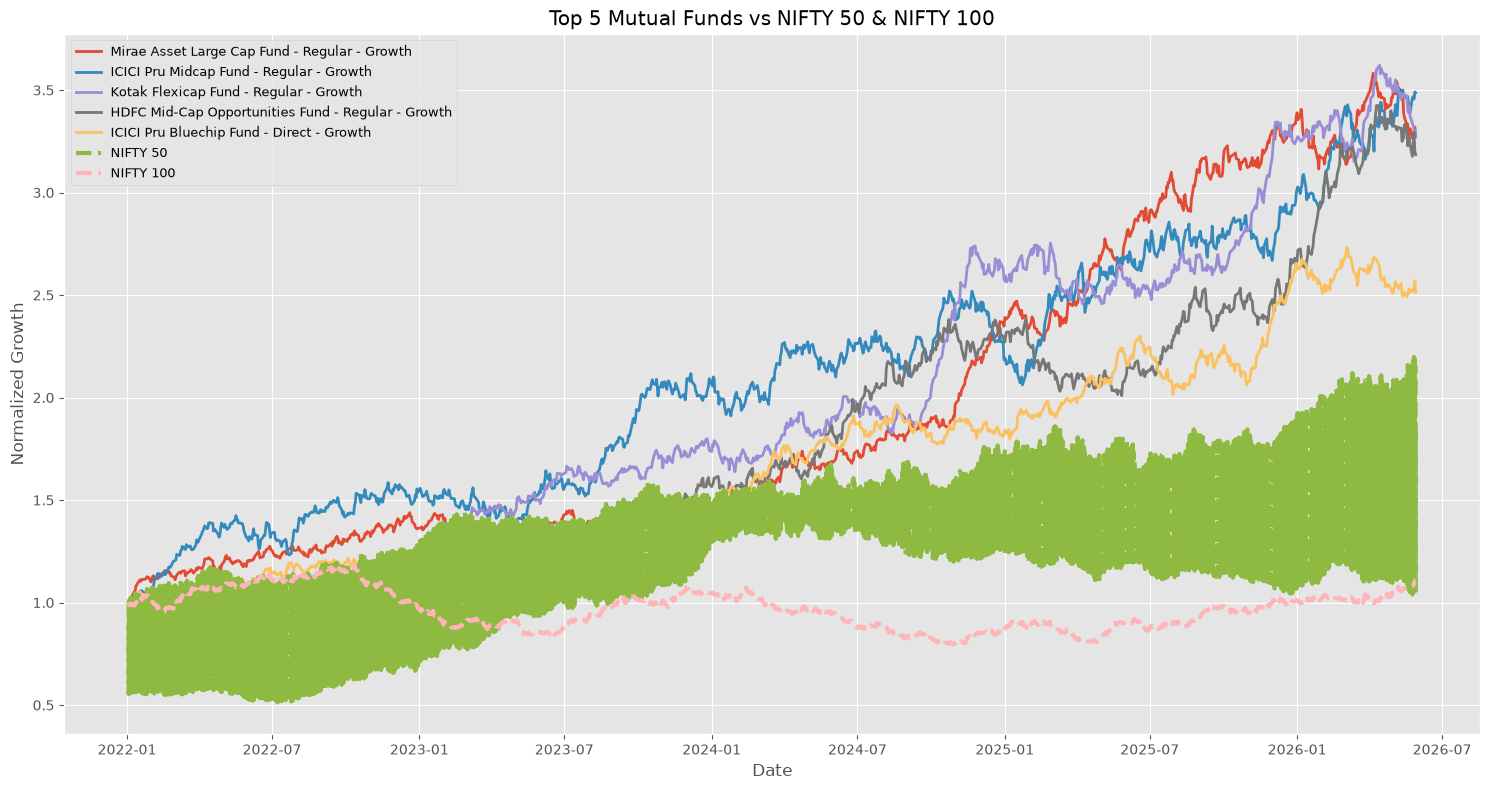

Chart saved to: c:\Users\khush\Desktop\MutualFundAnalytics\charts\benchmark_comparison.png


In [79]:
# ============================================================
# Benchmark Comparison Chart
# ============================================================

plt.figure(figsize=(15, 8))

top5 = score_df.head(5)["scheme_name"].tolist()

# Plot Top 5 Funds
for scheme in top5:

    temp = (
        nav_df[nav_df["scheme_name"] == scheme]
        .sort_values("full_date")
        .copy()
    )

    normalized = temp["nav"] / temp["nav"].iloc[0]

    plt.plot(
        temp["full_date"],
        normalized,
        linewidth=2,
        label=scheme
    )

# Plot Benchmarks
for benchmark in ["NIFTY 50", "NIFTY 100"]:

    temp = benchmark_df[
        benchmark_df["index_name"]
        .str.upper()
        .str.contains(
            benchmark.replace(" ", "")
            .replace("NIFTY", "")
        )
    ].copy()

    temp = temp.sort_values("date")

    if len(temp) == 0:
        continue

    normalized = (
        temp["close_value"] /
        temp["close_value"].iloc[0]
    )

    plt.plot(
        temp["date"],
        normalized,
        linewidth=3,
        linestyle="--",
        label=benchmark
    )

plt.title("Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100")

plt.xlabel("Date")

plt.ylabel("Normalized Growth")

plt.legend(fontsize=9)

plt.grid(True)

plt.tight_layout()

chart_path = CHART_DIR / "benchmark_comparison.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [80]:
# ============================================================
# Validation
# ============================================================

print("=" * 60)
print("DAY 4 VALIDATION")
print("=" * 60)

print(f"Funds analysed       : {len(score_df)}")
print(f"Alpha/Beta rows      : {len(alpha_beta_df)}")
print(f"Tracking Error rows  : {len(tracking_error_df)}")

print()

print("Top 10 Funds")

display(
    score_df[
        [
            "scheme_name",
            "Fund_Score",
            "CAGR_3Y",
            "Sharpe_Ratio",
            "Alpha",
            "Beta"
        ]
    ].head(10)
)

print()

print("Files Created")

print(alpha_beta_path.exists())
print(scorecard_path.exists())
print(chart_path.exists())

DAY 4 VALIDATION
Funds analysed       : 40
Alpha/Beta rows      : 40
Tracking Error rows  : 40

Top 10 Funds


,scheme_name,Fund_Score,CAGR_3Y,Sharpe_Ratio,Alpha,Beta
25,Mirae Asset Large Cap Fund - Regular - Growth,85.625000,0.340009,1.448291,0.269838,0.023684
18,ICICI Pru Midcap Fund - Regular - Growth,81.625000,0.317775,1.180101,0.292636,0.000549
22,Kotak Flexicap Fund - Regular - Growth,81.375000,0.295828,1.306744,0.273305,-0.022830
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.125000,0.324425,1.093699,0.271954,0.005104
15,ICICI Pru Bluechip Fund - Direct - Growth,79.375000,0.324874,1.026524,0.211948,0.016232
5,Axis Midcap Fund - Regular - Growth,76.375000,0.351118,0.998231,0.260767,-0.066265
33,SBI Bluechip Fund - Regular Plan - Growth,74.187500,0.304565,1.208267,0.232010,-0.031751
26,Mirae Asset Tax Saver Fund - Regular - Growth,73.062500,0.291789,1.234930,0.282704,0.018134
0,ABSL Frontline Equity Fund - Regular - Growth,67.562500,0.289677,1.027213,0.213998,0.021086
36,SBI Small Cap Fund - Regular Plan - Growth,66.750000,0.266699,0.945308,0.303370,-0.023196



Files Created
True
True
True


In [81]:
# ============================================================
# Close SQLite Connection
# ============================================================

conn.close()

print("Database connection closed.")

Database connection closed.
